In [1]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import itertools
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from dotenv import load_dotenv
from scipy import stats

In [2]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
stim_modality = "visual" # modality of decoded stimuli

# Classification performance in HC

## Visual predicted stimuli

In [3]:
# Load decoding data from each HC subfield
ROI_list = ["CA1", "CA3", "GC_DG", "subiculum", "HC"]
df_list = []
for ROI in ROI_list:
    df = pd.read_csv(f"{DATA_PATH}/{ROI}_wholeROI_{stim_modality}/balanced_group_data.csv")
    df["subfield"] = ROI
    df_list.append(df)
HCdecoding_df = pd.concat(df_list, ignore_index=True)

CA1 decoding accuracy
auditory runs: 0.51, p = 0.1537, n = 24
visual runs: 0.49, p = 0.9967, n = 24
CA3 decoding accuracy
auditory runs: 0.50, p = 0.8463, n = 24
visual runs: 0.50, p = 0.5806, n = 24
GC_DG decoding accuracy
auditory runs: 0.51, p = 0.1537, n = 24
visual runs: 0.51, p = 0.0758, n = 24
HC decoding accuracy
auditory runs: 0.51, p = 0.0539, n = 25
visual runs: 0.49, p = 0.5000, n = 25
subiculum decoding accuracy
auditory runs: 0.49, p = 0.9242, n = 24
visual runs: 0.50, p = 0.5806, n = 24


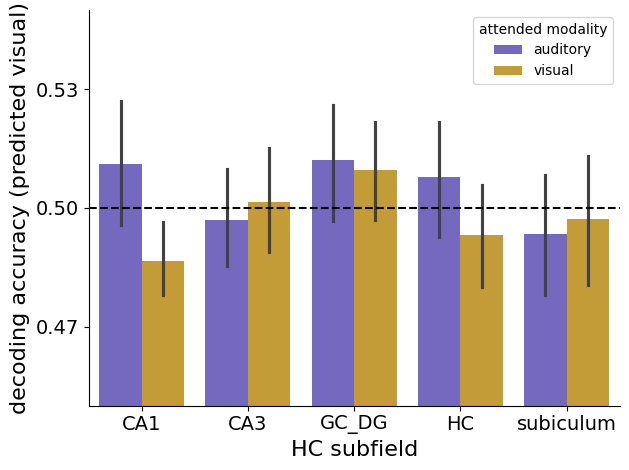

In [5]:
dat = HCdecoding_df.copy().groupby(["subj", "subfield", "modality"], as_index=0)["correct"].mean().reset_index()
savefig = True
sns.barplot(data=dat, x="subfield", y="correct", hue="modality", palette=["slateblue", "goldenrod"], ci=95)
plt.ylabel("decoding accuracy (predicted visual)", fontsize=16)
plt.xlabel("HC subfield", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(ticks=[0.47, 0.5, 0.53], labels=["0.47", "0.50", "0.53"], fontsize=14)
plt.legend(title="attended modality")
plt.ylim(0.45, 0.55)
plt.axhline(y=0.5, color="k", linestyle="--")
sns.despine()
plt.tight_layout()
if savefig:
    plt.savefig(f"figures/HC/{stim_modality}_decoding.svg", dpi=300)
for subfield in dat["subfield"].unique():
    print(f"{subfield} decoding accuracy")
    for modality in dat["modality"].unique():
        dat_subfield_modality = dat[(dat["subfield"] == subfield) & (dat["modality"] == modality)] 
        result = stats.binomtest(sum(dat_subfield_modality["correct"] > 0.5), len(dat_subfield_modality), 0.5, alternative="greater") # bionomial test
        print(f"{modality} runs: {dat_subfield_modality['correct'].mean():.2f}, p = {result.pvalue:.4f}, n = {len(dat_subfield_modality)}")
    

# Modeling classification probabilities in EVC based on predicted stimuli and HC subfields activation

## Load data

In [6]:
ROI = "EVC"
N_VOXELS = "wholeROI"
# The dataframe with all trials will be used to fit regression models with trial by trial measures
# The reason for this is that before fitting we need to aggreggate the data of each trial across permutations
# This can't be done with the balanced data bacause of the random sampling, which leads to non-idential sets of trial indices from each permutation
alltrials_df = pd.read_csv(f"{DATA_PATH}/{ROI}_{N_VOXELS}/group_data.csv") 
alltrials_df = alltrials_df[alltrials_df["subj"] != "sub-22"] # HC subfield data for this subject is not available
            
alltrials_df["correct"] = alltrials_df["correct"].astype(int)
alltrials_df["pred"] = alltrials_df["pred"].astype(str)
alltrials_df["ign_pred"] = alltrials_df["ign_pred"].astype(str)
alltrials_df["v_pred"] = np.where(alltrials_df["modality"] == "visual", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["a_pred"] = np.where(alltrials_df["modality"] == "auditory", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype(str)
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype(str)
alltrials_df["expected_stim"] = np.where(alltrials_df["expected_stim"] == 0, "CW", "CCW")
alltrials_df["stim"] = np.where(alltrials_df["stim"] == 0, "CW", "CCW")

# Aggregate across perms, while retaining important columns
alltrials_df = alltrials_df.groupby(['subj', 'run', 'trial']).agg(
    correct=('correct', 'mean'), 
    modality=('modality', 'first'),
    v_pred=('v_pred', 'first'),
    a_pred=('a_pred', 'first'),
    v_learned=('v_learned', 'first'),
    a_learned=('a_learned', 'first'),
    classified_stim=('classified_stim', 'mean'),
    stim = ('stim', 'first'),
    expected_stim=('expected_stim', 'first'),
    z_distance=('z_distance', 'mean'),
    decision_distances=('decision_distances', 'mean'),
    prob_0=('prob_0', 'mean'),
    prob_1=('prob_1', 'mean'),
    CA1=('CA1', 'mean'),
    CA3=('CA3', 'mean'),
    GC_DG=('GC_DG', 'mean'),
    subiculum=('subiculum', 'mean'),
    HC=('bilateralHC', 'mean'),
).reset_index()

# Binarize the 'correct' column
alltrials_df['correct'] = alltrials_df['correct'].round()

## Model interactions between subfield activity, expected stimulus and explicit knowledge

In [7]:
alltrials_df["expected_stim"] = alltrials_df["expected_stim"].astype("category")
alltrials_df["stim"] = alltrials_df["stim"].astype("category")
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype("category")
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype("category")
alltrials_df["a_pred"] = alltrials_df["a_pred"].astype("category")

# Applying logit transformation to the probabilities so that we can apply linear regression
# Adjust values to avoid issues with 0 and 1
alltrials_df['prob_1_adj'] = alltrials_df['prob_1'].clip(1e-6, 1-1e-6)

# Apply the logit transformation
alltrials_df['logit_prob'] = np.log(alltrials_df['prob_1_adj'] / (1 - alltrials_df['prob_1_adj']))

### CA1

In [35]:
subfield_ROI = "CA1"
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"logit_prob ~ expected_stim * {subfield_ROI} * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         logit_prob
No. Observations:          3456            Method:                     REML      
No. Groups:                24              Scale:                      0.1560    
Min. group size:           144             Log-Likelihood:             inf       
Max. group size:           144             Converged:                  Yes       
Mean group size:           144.0                                                 
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                               0.000                                    
expected_stim[T.CW]                     0.080    0.020  3.944 0.000  0.040  0.120
v_learned[T.1]                        

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundar

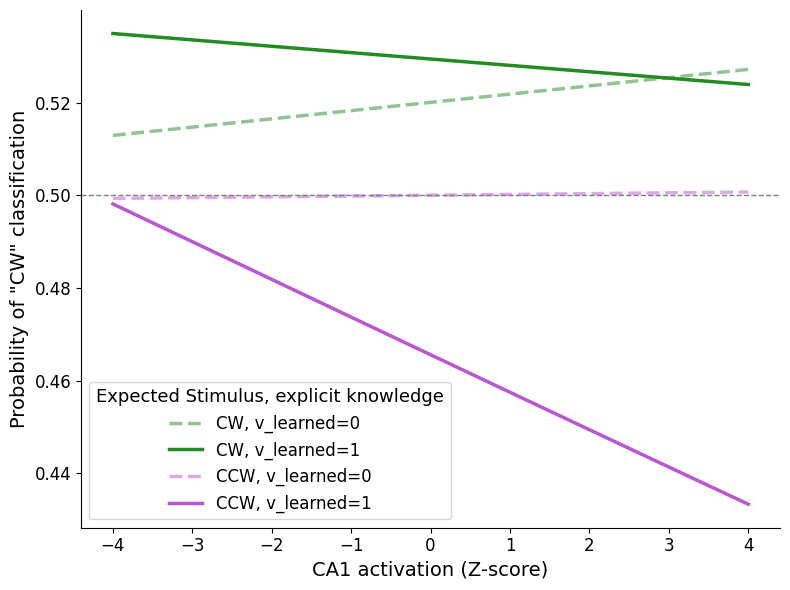

In [ ]:
# Generate artificial dataset
ROI_values = np.linspace(-4, 4, 100)
expected_stim_levels = ["CW", "CCW"]
v_learned_levels = ["0", "1"]

grid = pd.DataFrame(list(itertools.product(expected_stim_levels, v_learned_levels, ROI_values)),
                    columns=["expected_stim", "v_learned", subfield_ROI])

# Match encoding with training data
grid["expected_stim"] = pd.Categorical(grid["expected_stim"], categories=dat["expected_stim"].unique())
grid["v_learned"] = pd.Categorical(grid["v_learned"], categories=dat["v_learned"].unique())

# Predict using fixed effects only
grid["predicted_prob"] = mdf.predict(exog=grid)

# Inverse logit transformation to get probabilities back
grid["predicted_prob"] = 1 / (1 + np.exp(-grid["predicted_prob"]))

# Plotting
savefig = False
plt.figure(figsize=(8, 6))
colors = {"CW": "forestgreen", "CCW": "mediumorchid"}

for expected_stim in grid["expected_stim"].unique():
    for v_learned in grid["v_learned"].unique():
        subset = grid[(grid["expected_stim"] == expected_stim) & (grid["v_learned"] == v_learned)]
        linestyle = "--" if v_learned == "0" else "-"
        alpha = 0.5 if v_learned == "0" else 1.0
        label = f"{expected_stim}, v_learned={v_learned}"
        
        sns.lineplot(data=subset, x=subfield_ROI, y="predicted_prob",
                     color=colors[expected_stim], linestyle=linestyle,
                     linewidth=2.5, alpha=alpha, label=label)

plt.ylabel('Probability of "CW" classification', fontsize=14)
plt.xlabel(f"{subfield_ROI} activation (Z-score)", fontsize=14)
plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Expected Stimulus, explicit knowledge", fontsize=12, title_fontsize=13)
plt.tight_layout()
sns.despine()
if savefig:
    plt.savefig(f"figures/HC/{subfield_ROI}_{stim_modality}_interaction.svg", dpi=300)
plt.show()


### CA3

In [38]:
subfield_ROI = "CA3"
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"logit_prob ~ expected_stim * {subfield_ROI} * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         logit_prob
No. Observations:          3456            Method:                     REML      
No. Groups:                24              Scale:                      0.1560    
Min. group size:           144             Log-Likelihood:             inf       
Max. group size:           144             Converged:                  Yes       
Mean group size:           144.0                                                 
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                               0.000                                    
expected_stim[T.CW]                     0.080    0.020  3.951 0.000  0.041  0.120
v_learned[T.1]                        

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundar

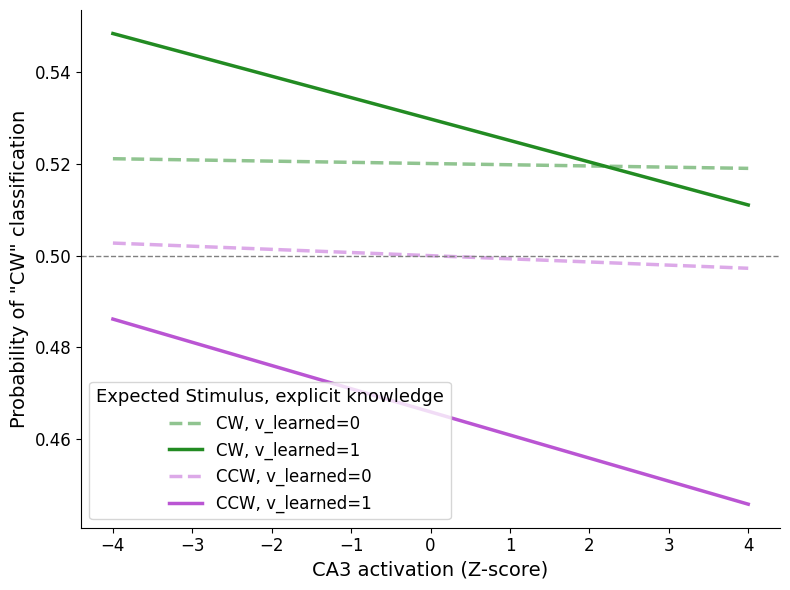

In [ ]:
# Generate artificial dataset
ROI_values = np.linspace(-4, 4, 100)
expected_stim_levels = ["CW", "CCW"]
v_learned_levels = ["0", "1"]

grid = pd.DataFrame(list(itertools.product(expected_stim_levels, v_learned_levels, ROI_values)),
                    columns=["expected_stim", "v_learned", subfield_ROI])

# Match encoding with training data
grid["expected_stim"] = pd.Categorical(grid["expected_stim"], categories=dat["expected_stim"].unique())
grid["v_learned"] = pd.Categorical(grid["v_learned"], categories=dat["v_learned"].unique())

# Predict using fixed effects only
grid["predicted_prob"] = mdf.predict(exog=grid)

# Inverse logit transformation to get probabilities back
grid["predicted_prob"] = 1 / (1 + np.exp(-grid["predicted_prob"]))

# Plotting
savefig = False
plt.figure(figsize=(8, 6))
colors = {"CW": "forestgreen", "CCW": "mediumorchid"}

for expected_stim in grid["expected_stim"].unique():
    for v_learned in grid["v_learned"].unique():
        subset = grid[(grid["expected_stim"] == expected_stim) & (grid["v_learned"] == v_learned)]
        linestyle = "--" if v_learned == "0" else "-"
        alpha = 0.5 if v_learned == "0" else 1.0
        label = f"{expected_stim}, v_learned={v_learned}"
        
        sns.lineplot(data=subset, x=subfield_ROI, y="predicted_prob",
                     color=colors[expected_stim], linestyle=linestyle,
                     linewidth=2.5, alpha=alpha, label=label)

plt.ylabel('Probability of "CW" classification', fontsize=14)
plt.xlabel(f"{subfield_ROI} activation (Z-score)", fontsize=14)
plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Expected Stimulus, explicit knowledge", fontsize=12, title_fontsize=13)
plt.tight_layout()
sns.despine()
if savefig:
    plt.savefig(f"figures/HC/{subfield_ROI}_{stim_modality}_interaction.svg", dpi=300)
plt.show()


### DG-CG

In [43]:
subfield_ROI = "GC_DG"
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"logit_prob ~ expected_stim * {subfield_ROI} * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                       Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          logit_prob
No. Observations:          3456             Method:                      REML      
No. Groups:                24               Scale:                       0.1560    
Min. group size:           144              Log-Likelihood:              inf       
Max. group size:           144              Converged:                   Yes       
Mean group size:           144.0                                                   
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 0.000                                    
expected_stim[T.CW]                       0.081    0.020  3.972 0.000  0.041  0.121
v_learned[T.1] 

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundar

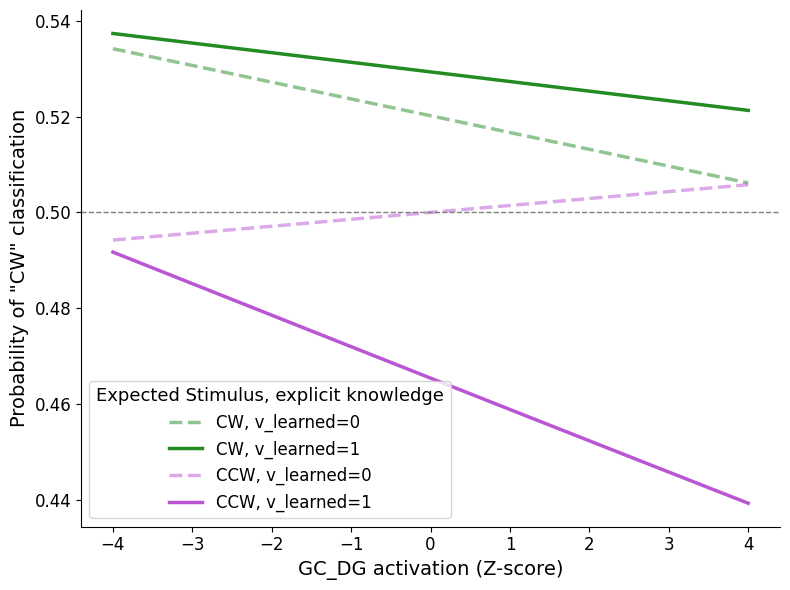

In [44]:
# Generate artificial dataset
ROI_values = np.linspace(-4, 4, 100)
expected_stim_levels = ["CW", "CCW"]
v_learned_levels = ["0", "1"]

grid = pd.DataFrame(list(itertools.product(expected_stim_levels, v_learned_levels, ROI_values)),
                    columns=["expected_stim", "v_learned", subfield_ROI])

# Match encoding with training data
grid["expected_stim"] = pd.Categorical(grid["expected_stim"], categories=dat["expected_stim"].unique())
grid["v_learned"] = pd.Categorical(grid["v_learned"], categories=dat["v_learned"].unique())

# Predict using fixed effects only
grid["predicted_prob"] = mdf.predict(exog=grid)

# Inverse logit transformation to get probabilities back
grid["predicted_prob"] = 1 / (1 + np.exp(-grid["predicted_prob"]))

# Plotting
savefig = True
plt.figure(figsize=(8, 6))
colors = {"CW": "forestgreen", "CCW": "mediumorchid"}

for expected_stim in grid["expected_stim"].unique():
    for v_learned in grid["v_learned"].unique():
        subset = grid[(grid["expected_stim"] == expected_stim) & (grid["v_learned"] == v_learned)]
        linestyle = "--" if v_learned == "0" else "-"
        alpha = 0.5 if v_learned == "0" else 1.0
        label = f"{expected_stim}, v_learned={v_learned}"
        
        sns.lineplot(data=subset, x=subfield_ROI, y="predicted_prob",
                     color=colors[expected_stim], linestyle=linestyle,
                     linewidth=2.5, alpha=alpha, label=label)

plt.ylabel('Probability of "CW" classification', fontsize=14)
plt.xlabel(f"{subfield_ROI} activation (Z-score)", fontsize=14)
plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Expected Stimulus, explicit knowledge", fontsize=12, title_fontsize=13)
plt.tight_layout()
sns.despine()
if savefig:
    plt.savefig(f"figures/HC/{subfield_ROI}_{stim_modality}_interaction.svg", dpi=300)
plt.show()


### Subiculum

In [8]:
subfield_ROI = "subiculum"
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"logit_prob ~ expected_stim * {subfield_ROI} * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           logit_prob
No. Observations:            3456              Method:                       REML      
No. Groups:                  24                Scale:                        0.1561    
Min. group size:             144               Log-Likelihood:               inf       
Max. group size:             144               Converged:                    Yes       
Mean group size:             144.0                                                     
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                     0.000                                    
expected_stim[T.CW]                           0.080    0.

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundar

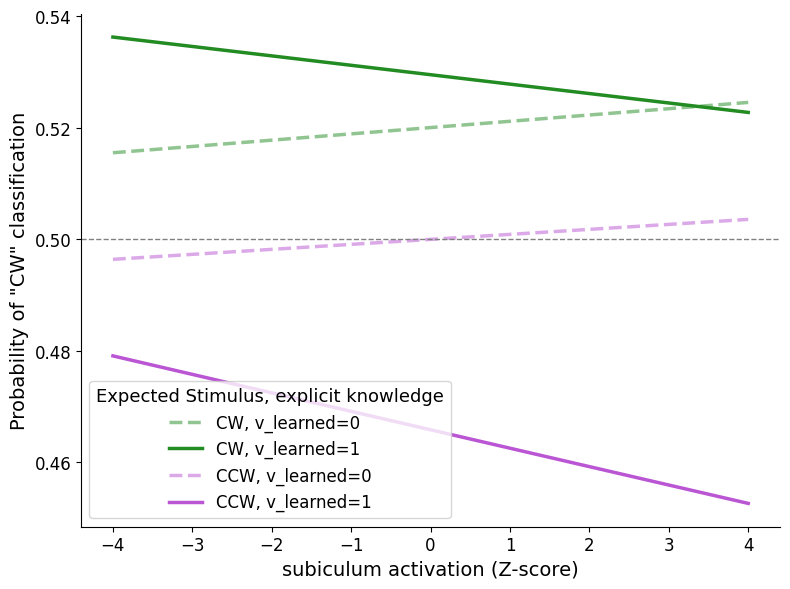

In [9]:
# Generate artificial dataset
ROI_values = np.linspace(-4, 4, 100)
expected_stim_levels = ["CW", "CCW"]
v_learned_levels = ["0", "1"]

grid = pd.DataFrame(list(itertools.product(expected_stim_levels, v_learned_levels, ROI_values)),
                    columns=["expected_stim", "v_learned", subfield_ROI])

# Match encoding with training data
grid["expected_stim"] = pd.Categorical(grid["expected_stim"], categories=dat["expected_stim"].unique())
grid["v_learned"] = pd.Categorical(grid["v_learned"], categories=dat["v_learned"].unique())

# Predict using fixed effects only
grid["predicted_prob"] = mdf.predict(exog=grid)

# Inverse logit transformation to get probabilities back
grid["predicted_prob"] = 1 / (1 + np.exp(-grid["predicted_prob"]))

# Plotting
savefig = True
plt.figure(figsize=(8, 6))
colors = {"CW": "forestgreen", "CCW": "mediumorchid"}

for expected_stim in grid["expected_stim"].unique():
    for v_learned in grid["v_learned"].unique():
        subset = grid[(grid["expected_stim"] == expected_stim) & (grid["v_learned"] == v_learned)]
        linestyle = "--" if v_learned == "0" else "-"
        alpha = 0.5 if v_learned == "0" else 1.0
        label = f"{expected_stim}, v_learned={v_learned}"
        
        sns.lineplot(data=subset, x=subfield_ROI, y="predicted_prob",
                     color=colors[expected_stim], linestyle=linestyle,
                     linewidth=2.5, alpha=alpha, label=label)

plt.ylabel('Probability of "CW" classification', fontsize=14)
plt.xlabel(f"{subfield_ROI} activation (Z-score)", fontsize=14)
plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Expected Stimulus, explicit knowledge", fontsize=12, title_fontsize=13)
plt.tight_layout()
sns.despine()
if savefig:
    plt.savefig(f"figures/HC/{subfield_ROI}_{stim_modality}_interaction.svg", dpi=300)
plt.show()
